In [78]:
%load_ext autoreload
%autoreload 

import numpy as np
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
print("Jax version", jax.__version__)
import distrax
print("Distrax version", distrax.__version__)
import flax
import flax.nnx as nnx
print("Flax version", flax.__version__)
import optax 
print("Optax version", optax.__version__)
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
print("PyTorch version", torch.__version__)

from sbi_compression.methods.neural.flows import RQSplineFlow
from sbi_compression.methods.neural.AEncoderFlow import AutoencoderFlow



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Jax version 0.10.0
Distrax version 0.1.8
Flax version 0.12.7
Optax version 0.2.8
PyTorch version 2.12.0


In [13]:
N_DATA = 8000
with np.load('../sbi_lens_sims/combined_overall.npz') as data:
    x = data['y'][:N_DATA]
    # Flax Conv layers expects data shape in (N, H, W, C) format
    p = data['theta'][:N_DATA]
    # Remove any NaN data points
    nan_mask = jnp.isnan(x).reshape(x.shape[0], -1).any(axis=1)
    clean_indices = jnp.where(~nan_mask)[0]
    x = x[clean_indices]
    p = p[clean_indices]
    N_data = x.shape[0]
    print("x", x.shape, "\np", p.shape)

x (7999, 60, 60, 5) 
p (7999, 6)


In [110]:
# Hyperparameters
n_features = 6
n_context = 6
key = jax.random.PRNGKey(42)
LEARNING_RATE = 1e-4
STEPS = 8000
TRAIN_TEST_SPLIT = 0.8
BATCH_SIZE = 128
PRINT_EVERY = 1000

# Model
VMIM = AutoencoderFlow(
    input_shape = (60,60,5),
    features_shape = (n_features,),
    context_shape = (n_context,),
    encoder_layer_dims = ((5,3,11), (3,1,11), (1,1,11), (30*30, 100), (100, n_features)),
    conditioner_hidden_dims = ((32,32), (32,32)),
    encoder_mode = 'context',
    activation = 'gelu',
    n_transforms = 4,
    n_bins = 6,
    range_min = -4.0,
    range_max = 4.0,
    bijector_type = distrax.RationalQuadraticSpline
)

# Loss function
def loss_fn(model, x, context):
    loss = -jnp.mean(model(x, context))
    return loss

# Optimiser
optimizer = nnx.Optimizer(
    VMIM, 
    optax.adamw(LEARNING_RATE),
    wrt=nnx.Param
)

@nnx.jit(static_argnames="loss_fn")
def train_step(model, optimizer: nnx.Optimizer, loss_fn, x_batch, context_batch):
    """Train for a single step."""
    loss_value, grads = nnx.value_and_grad(loss_fn)(model, x_batch, context_batch)
    optimizer.update(model, grads)  # In-place updates.
    return loss_value

@nnx.jit(static_argnames="loss_fn")
def eval_step(model, loss_fn, x, y):
    """Calculate loss on test data without updating parameters."""
    loss_value = loss_fn(model, x, y)
    return loss_value

def infinite_trainloader():
    while True:
        yield from train_loader

train_losses = []
test_losses = []
test_steps = []


x_tensor = torch.tensor(np.array(x), dtype=torch.float32)
p_tensor = torch.tensor(np.array(p), dtype=torch.float32)
dataset = TensorDataset(x_tensor, p_tensor)
train_size = int(TRAIN_TEST_SPLIT * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)


for step, (x_batch, p_batch) in tqdm(zip(range(STEPS), infinite_trainloader())):
    train_loss = train_step(VMIM, optimizer, loss_fn, p_batch.numpy(), x_batch.numpy()) # Posteriior Estimation
    train_losses.append(train_loss)
    # --- EVALUATION PHASE ---
    if step % PRINT_EVERY == 0:
        # metrics.reset() # Clear training metrics to track test metrics
        test_loss = 0
        for batch_x, batch_p in test_loader:
            test_loss += eval_step(VMIM, loss_fn, batch_p.numpy(), batch_x.numpy())
        test_loss /= len(test_loader)
        test_losses.append(test_loss)
        test_steps.append(step)
        print(f"Step {step:3d} ({(step*BATCH_SIZE)/train_size:.1f} epoch) | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
print("Training completed.")



23it [00:01, 23.18it/s]

Step   0 (0.0 epoch) | Train Loss: 8.565535 | Test Loss: 8.285080


1034it [01:13, 16.33it/s]

Step 1000 (20.0 epoch) | Train Loss: -6.079382 | Test Loss: -6.113005


2033it [02:27, 15.70it/s]

...

Step 6000 (120.0 epoch) | Train Loss: -6.397228 | Test Loss: -6.399552


7029it [08:53, 14.27it/s]

Step 7000 (140.0 epoch) | Train Loss: -6.513900 | Test Loss: -6.361931


8000it [10:10, 13.10it/s]

Training completed.


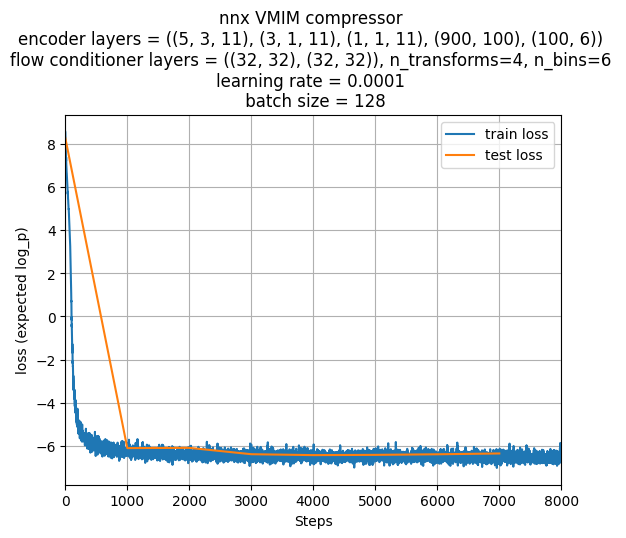

(7999, 6) (7999, 6)


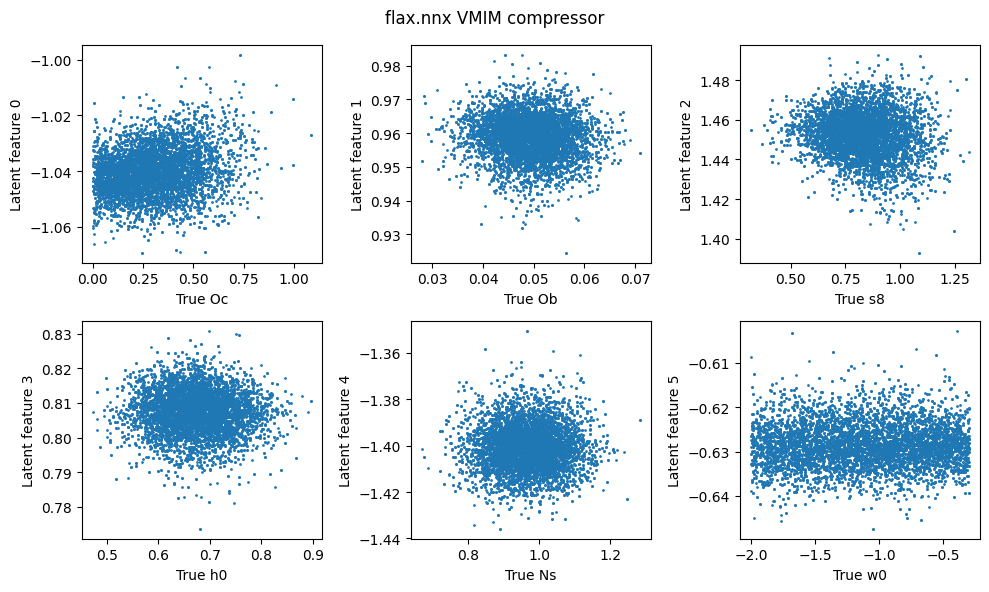

In [112]:
# Training loss time series
fig, ax = plt.subplots()
ax.plot(range(STEPS), train_losses, label='train loss')
ax.plot(test_steps, test_losses, label='test loss')
ax.set_xlim(0,STEPS)
plt.grid()
plt.legend()
plt.xlabel("Steps")
plt.ylabel("loss (expected log_p)")
plt.title(f"nnx VMIM compressor \nencoder layers = {VMIM.encoder_layer_dims} \nflow conditioner layers = {VMIM.conditioner_hidden_dims}, n_transforms={VMIM.n_transforms}, n_bins={VMIM.n_bins} \nlearning rate = {LEARNING_RATE} \n batch size = {BATCH_SIZE}")
plt.savefig(f"plots/nnx_VMIM_loss_{STEPS}_steps.pdf")
plt.show()


# Truth vs Latent diagnostic scatter
gt = ground_truth = p
cd = compressed_data = VMIM.encode(x)
results = {
    "ground_truth": gt,
    "compressed_data": cd,
    "train_losses": train_losses,
    "test_losses": test_losses,
    "test_steps": test_steps
}
path = f"compressed_data/VMIM_{VMIM.n_transforms}transforms_{VMIM.n_bins}bins_min{VMIM.range_min}_max{VMIM.range_max}.pkl"
with open(path, 'wb') as f:
    pickle.dump(results, f)
print(compressed_data.shape, p.shape)

params = ['Oc','Ob','s8','h0','Ns','w0']
num_params = ground_truth.shape[1]

fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()
for i in range(num_params):
    ax = axes[i]
    ax.scatter(gt[:,i], cd[:,i], s=1)
    ax.set_xlabel(f'True {params[i]}')
    ax.set_ylabel(f'Latent feature {i}')

plt.suptitle("flax.nnx VMIM compressor")
plt.tight_layout()
# plt.savefig(f"plots/nnx_VMIM_scatter_{STEPS}_steps.pdf")
plt.show()

In [91]:
import pickle

# --- SAVING ---
# 1. Get the model state (parameters, batch stats, etc.)
state = nnx.state(VMIM, nnx.Param)

# 2. Save it to a file
with open('checkpoints/autoencoder_flow_v1.pkl', 'wb') as f:
    pickle.dump(state, f)

# --- LOADING ---
# 1. Create a fresh instance of the model with the SAME hyperparameters
new_model = AutoencoderFlow(
    input_shape = (60,60,5),
    features_shape = (n_features,),
    context_shape = (n_context,),
    encoder_layer_dims = ((5,3,11), (3,1,11), (1,1,11), (30*30, 100), (100, n_features)),
    conditioner_hidden_dims = ((32,32), (32,32)),
    encoder_mode = 'context',
    activation = 'gelu',
    n_transforms = 4,
    n_bins = 10,
    range_min = -4.0,
    range_max = 4.0,
    bijector_type = distrax.RationalQuadraticSpline
)

# 2. Load the state from the file
with open('checkpoints/autoencoder_flow_v1.pkl', 'rb') as f:
    loaded_state = pickle.load(f)

# 3. Update the model with the loaded state
nnx.update(new_model, loaded_state)



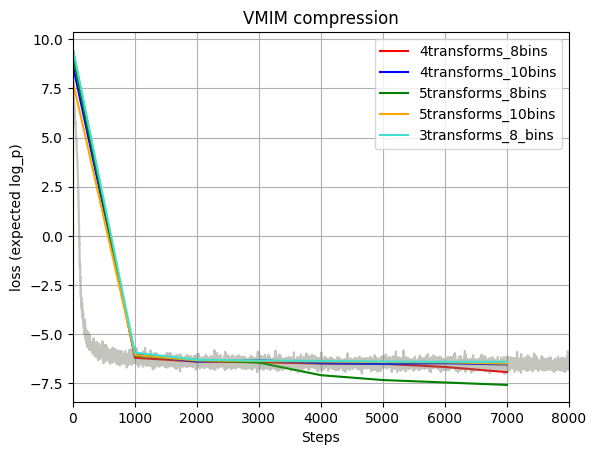

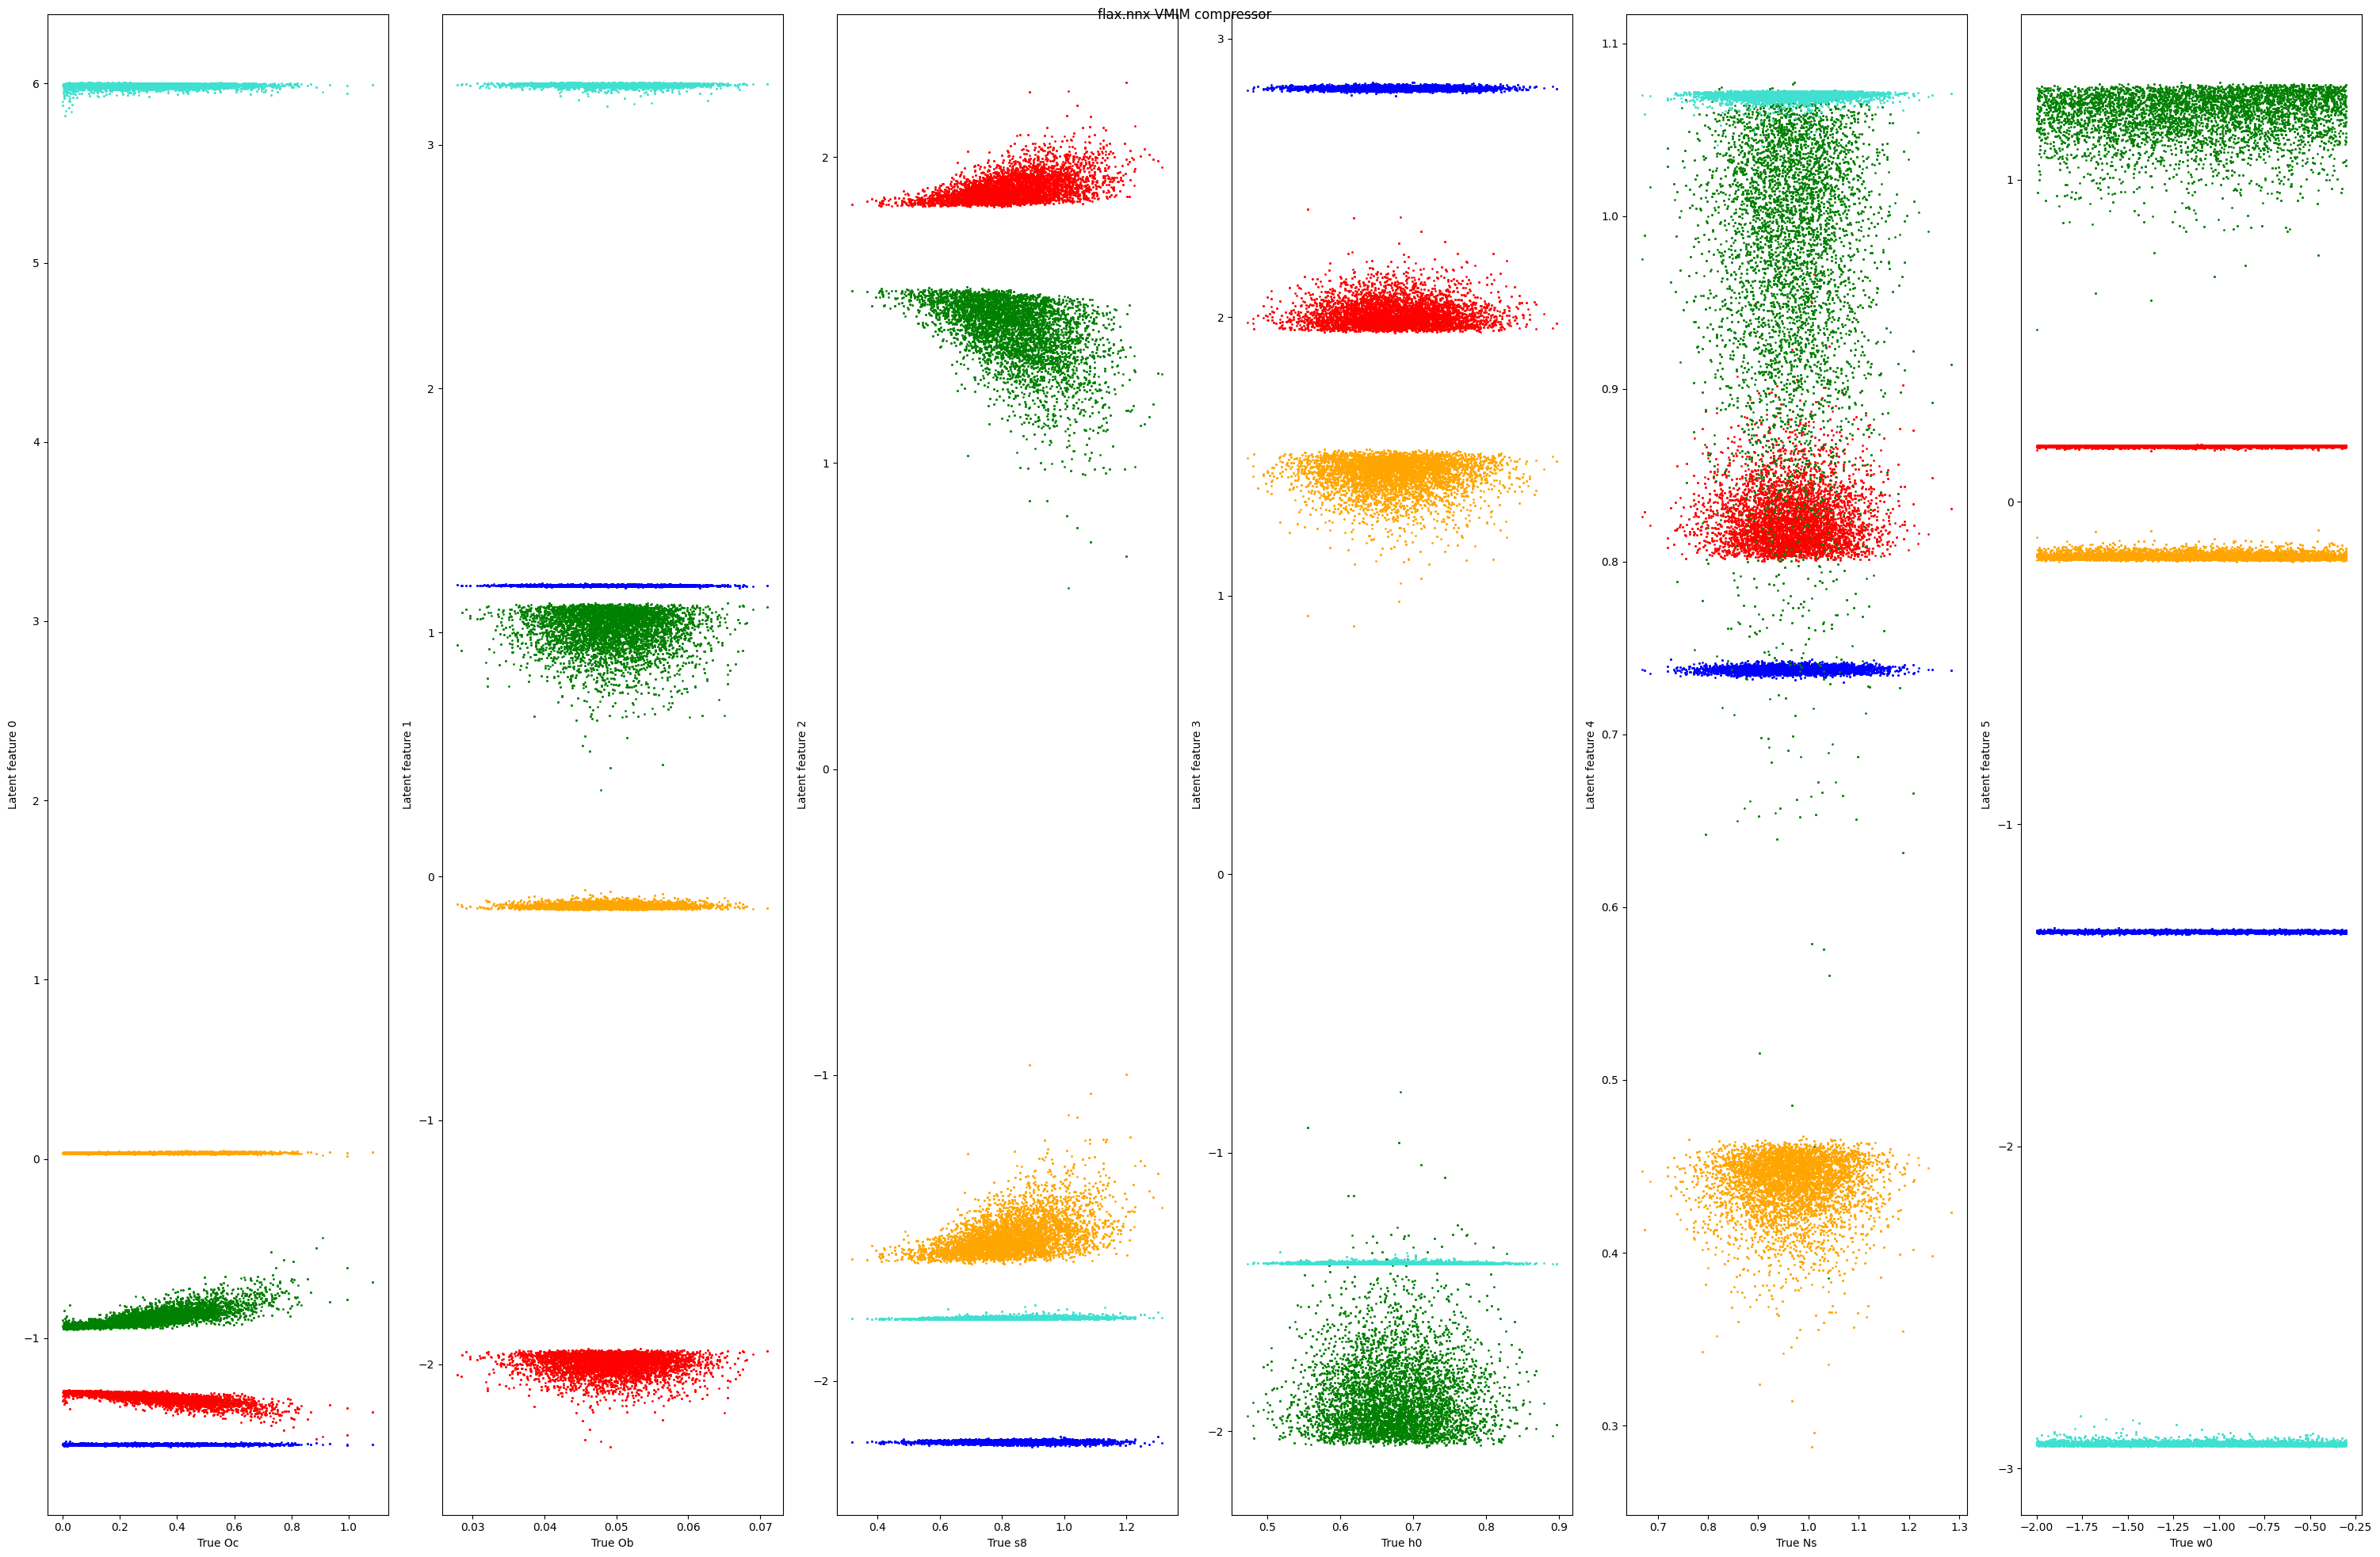

In [ ]:
results_files = [
    "VMIM_4transforms_8bins_min-4.0_max4.0.pkl",
    "VMIM_4transforms_10bins_min-4.0_max4.0.pkl",
    "VMIM_5transforms_8bins_min-4.0_max4.0.pkl",
    "VMIM_5transforms_10bins_min-4.0_max4.0.pkl",
    "VMIM_3transforms_8bins_min-4.0_max4.0.pkl",
]
labels = [
    "4transforms_8bins",
    "4transforms_10bins",
    "5transforms_8bins",
    "5transforms_10bins",
    "3transforms_8_bins",
]
colours = [
    "red",
    "blue",
    "green",
    "orange",
    "turquoise"
]

# Training loss time series
fig, ax = plt.subplots()
for r,l,c in zip(results_files,labels,colours):
    with open("compressed_data/"+r, 'rb') as f:
        load = pickle.load(f)
        train_lossses = load["train_losses"]
        test_losses = load["test_losses"]
        test_steps = load["test_steps"]
        ax.plot(range(STEPS), train_losses, color=c, alpha=0.1)
        ax.plot(test_steps, test_losses, label=l, color=c)
        ax.set_xlim(0,STEPS)
plt.grid()
plt.legend()
plt.xlabel("Steps")
plt.ylabel("loss (expected log_p)")
plt.title(f"VMIM compression")
plt.show()


# Truth vs Latent diagnostic scatter
fig, axes = plt.subplots(1, 6, figsize=(30,20))
axes = axes.flatten()
params = ['Oc','Ob','s8','h0','Ns','w0']
for r,l,c in zip(results_files,labels,colours):
    with open("compressed_data/"+r, 'rb') as f:
        load = pickle.load(f)
        gt = load["ground_truth"]
        cd = load["compressed_data"]
        num_params = gt.shape[1]
        for i in range(num_params):
            ax = axes[i]
            ax.scatter(gt[:,i], cd[:,i], s=1, color=c, label=l)
            ax.set_xlabel(f'True {params[i]}')
            ax.set_ylabel(f'Latent feature {i}')
plt.suptitle("flax.nnx VMIM compressor")
plt.tight_layout()
plt.show()